# Imports

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.pylab import rcParams
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.tools import diff
!pip3 install pmdarima
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import norm
import statsmodels.api as sm
import requests
from io import BytesIO
from zipfile import ZipFile
import warnings
warnings.filterwarnings("ignore") # To prevent kernel from showing any warning
plt.style.use('fivethirtyeight')

Found existing installation: numpy 1.26.3
Uninstalling numpy-1.26.3:
  Successfully uninstalled numpy-1.26.3
  Using cached numpy-1.26.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.9 MB/s eta 0:00:00


# Excel File Inserted Here

In [ ]:
# df = pd.read_excel("C:/Users/zhiyu/MATLAB Drive/FYP Codes/Datasets/daily.xlsx")
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")
df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
df = df[['activePowerT','activePowerA','currentA']]

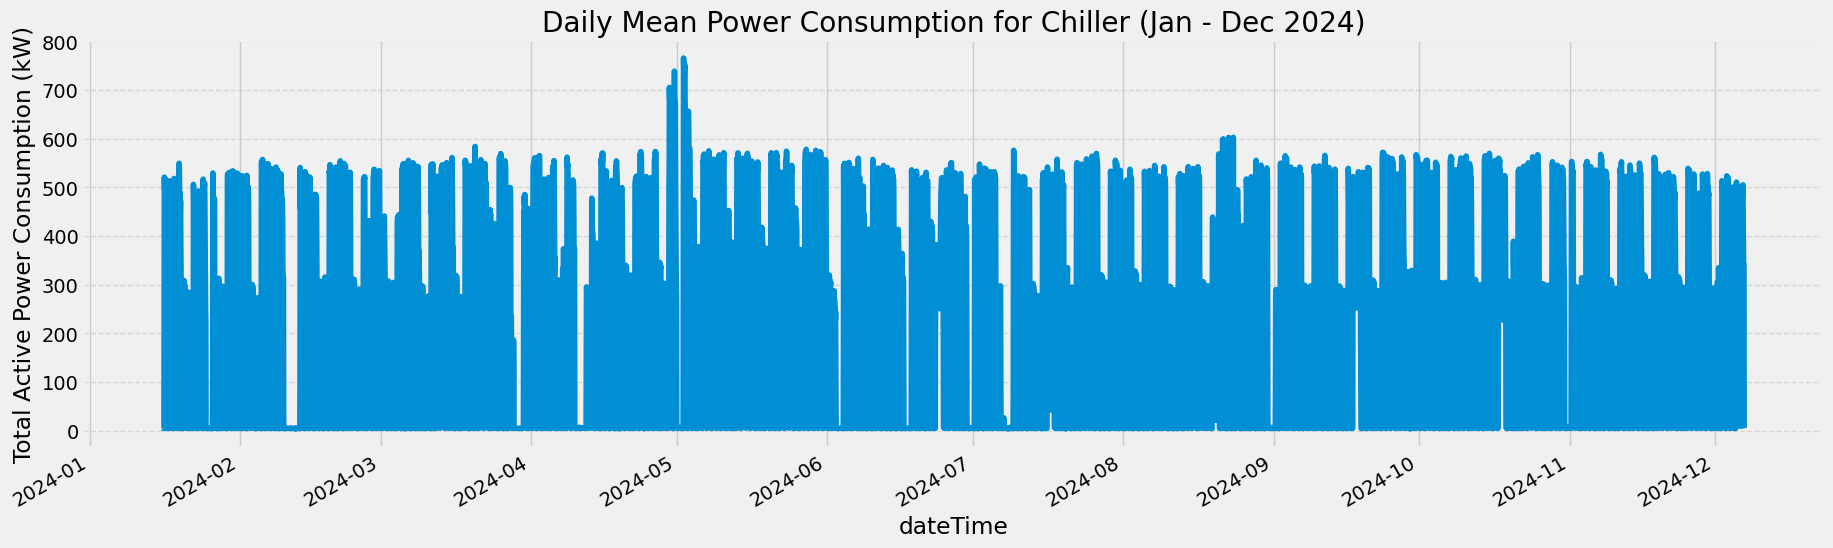

In [ ]:
img= df['activePowerT'].plot(figsize=(20,6),title="Daily Mean Power Consumption for Chiller (Jan - Dec 2024)")
img.set_xlabel('dateTime')
img.set_ylabel('Total Active Power Consumption (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

fig = img.get_figure()
fig.savefig('/content/drive/MyDrive/Images/SARIMAX/daily')

## Check for Outliers

In [ ]:
Q1 = df['activePowerT'].quantile(0.25)
Q3 = df['activePowerT'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(lower)
print(upper)
df_outlier = df[(df['activePowerT'] < lower) & (df['activePowerT'] > upper)]

-672.2918125000001
1134.2716875


In [ ]:
df.describe()

,activePowerT,activePowerA,currentA
count,7822.000000,7822.000000,7822.000000
mean,210.511814,62.688996,337.176125
std,221.561291,65.806205,350.905706
min,3.560500,0.713500,3.348500
25%,5.169500,1.448500,6.473500
50%,136.328750,41.508000,224.900000
75%,456.810375,137.993125,748.425750
max,765.351000,221.873000,1190.637500


## Boxplot for Dataset

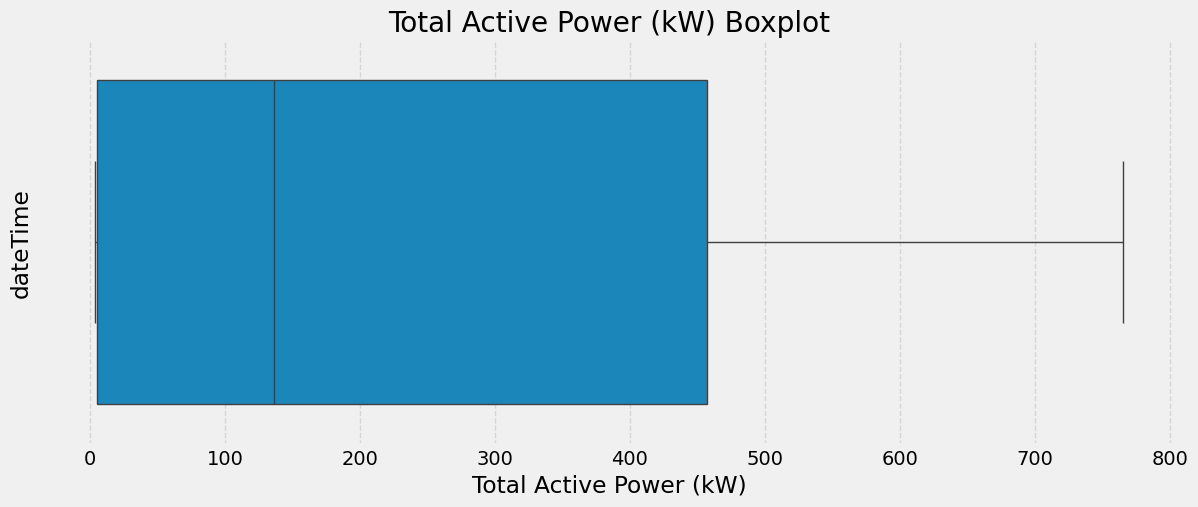

In [ ]:
fig,ax = plt.subplots(figsize=(13,5))
sns.boxplot(data=df, x="activePowerT", whis=(0, 100),ax=ax)
ax.set_ylabel('dateTime')
ax.set_xlabel('Total Active Power (kW)')
ax.set_title('Total Active Power (kW) Boxplot')


plt.grid(axis='x', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/SARIMAX/boxplot')
plt.show()

# Check for stationary

In [ ]:
def adf_test(data):
  print ('Results of ADF Test:')
  result = adfuller(data,regression='ct',maxlag=24)
  print(f'ADF Statistic : {result[0]}')
  print(f'p-value : {result[1]}')
  print(f'Critical Values:{result[4]}')


def kpss_test(timeseries):
    print ('Results of KPSS Test:')
    result = kpss(timeseries, regression='ct',nlags=24)
    print(f'KPSS Statistic : {result[0]}')
    print(f'p-value : {result[1]}')
    print(f'Critical Values:{result[3]}')

In [ ]:
adf_test(df['activePowerT'])
kpss_test(df['activePowerT'])

Results of ADF Test:
ADF Statistic : -11.57603118124866
p-value : 1.9815916069020856e-18
Critical Values:{'1%': -3.9599315683242837, '5%': -3.411053237098068, '10%': -3.127381679333959}
Results of KPSS Test:
KPSS Statistic : 0.24094487344181933
p-value : 0.01
Critical Values:{'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


ADF concludes stationary, and KPSS concludes non-stationary. The results above imply that the time series above is trend-stationary instead of strictly stationary. This means that the series becomes stationary after detrending The series is difference stationary. Differencing is to be used to make series stationary. Then we check the differenced series for stationarity.

In [ ]:
df['activePower_diff']= df['activePowerT'].diff(periods=24)
df.dropna(inplace=True)

adf_test(df['activePower_diff'])
kpss_test(df['activePower_diff'])

Results of ADF Test:
ADF Statistic : -15.662726572517842
p-value : 1.265970726978886e-22
Critical Values:{'1%': -3.95993515624541, '5%': -3.4110549766160436, '10%': -3.12738270363096}
Results of KPSS Test:
KPSS Statistic : 0.0028790610024735045
p-value : 0.1
Critical Values:{'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


Since our time series data has a clear seasonality, we will use seasonal differencing to achieve stationarity. This is verified using the adf and kpss test.

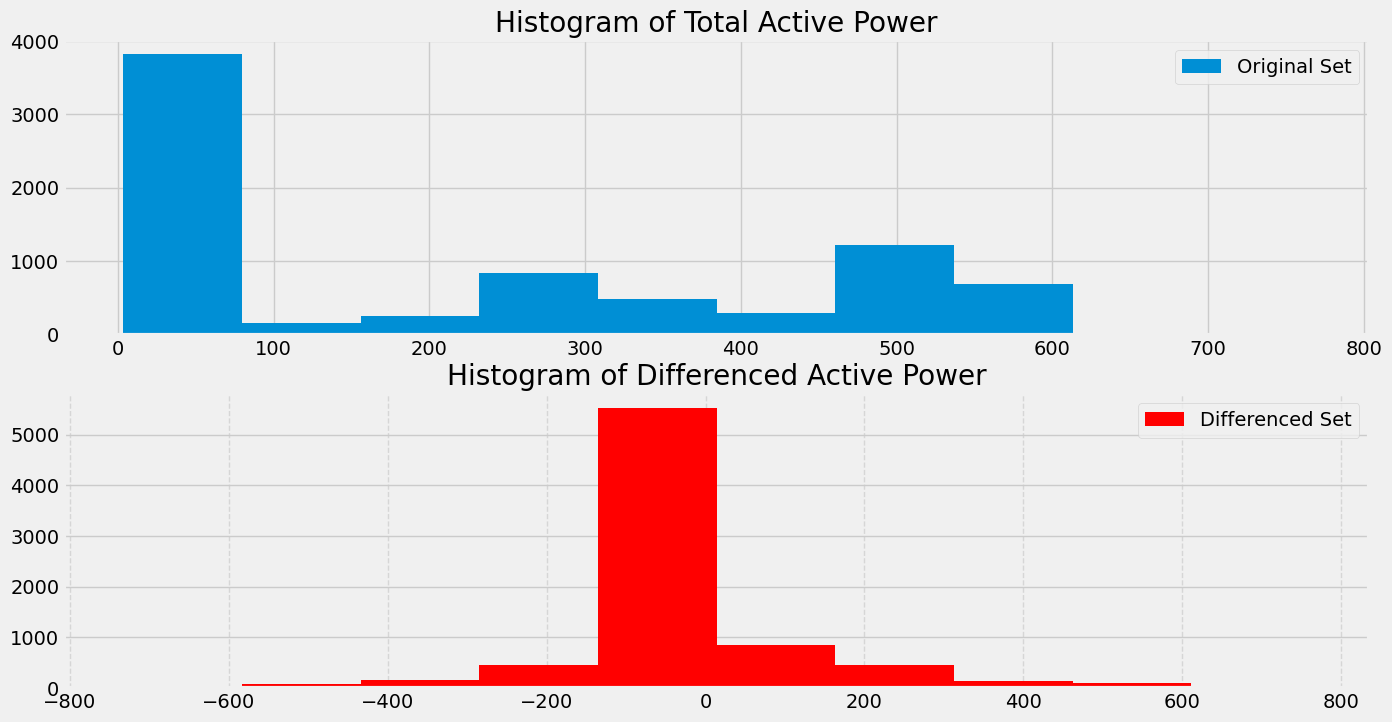

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(15,8))
df['activePowerT'].hist(ax=ax[0],label="Original Set")
df['activePower_diff'].hist(ax=ax[1], label="Differenced Set",color='red')
ax[0].legend()
ax[0].set_title('Histogram of Total Active Power')
ax[1].legend()
ax[1].set_title('Histogram of Differenced Active Power')

plt.grid(axis='x', linestyle='--', alpha=0.7)
fig.savefig('/content/drive/MyDrive/Images/SARIMAX/histogram')
plt.show()



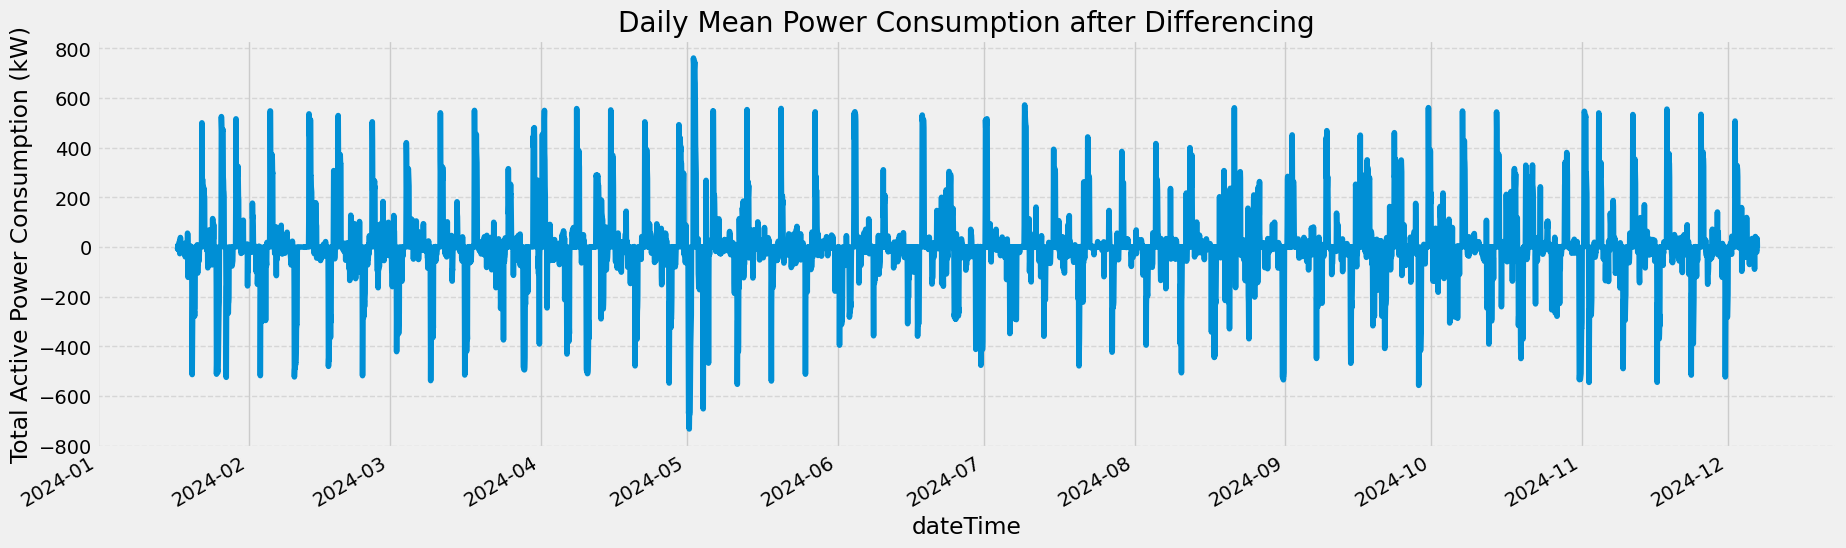

In [ ]:
img = df['activePower_diff'].plot(figsize=(20,6),title="Daily Mean Power Consumption after Differencing")
img.set_xlabel('dateTime')
img.set_ylabel('Total Active Power Consumption (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

fig = img.get_figure()
fig.savefig('/content/drive/MyDrive/Images/SARIMAX/diff')

  Non Seasonal Model is identified by non seasonal beviors of SAC and SPAC, consider the seasonal model tentatively

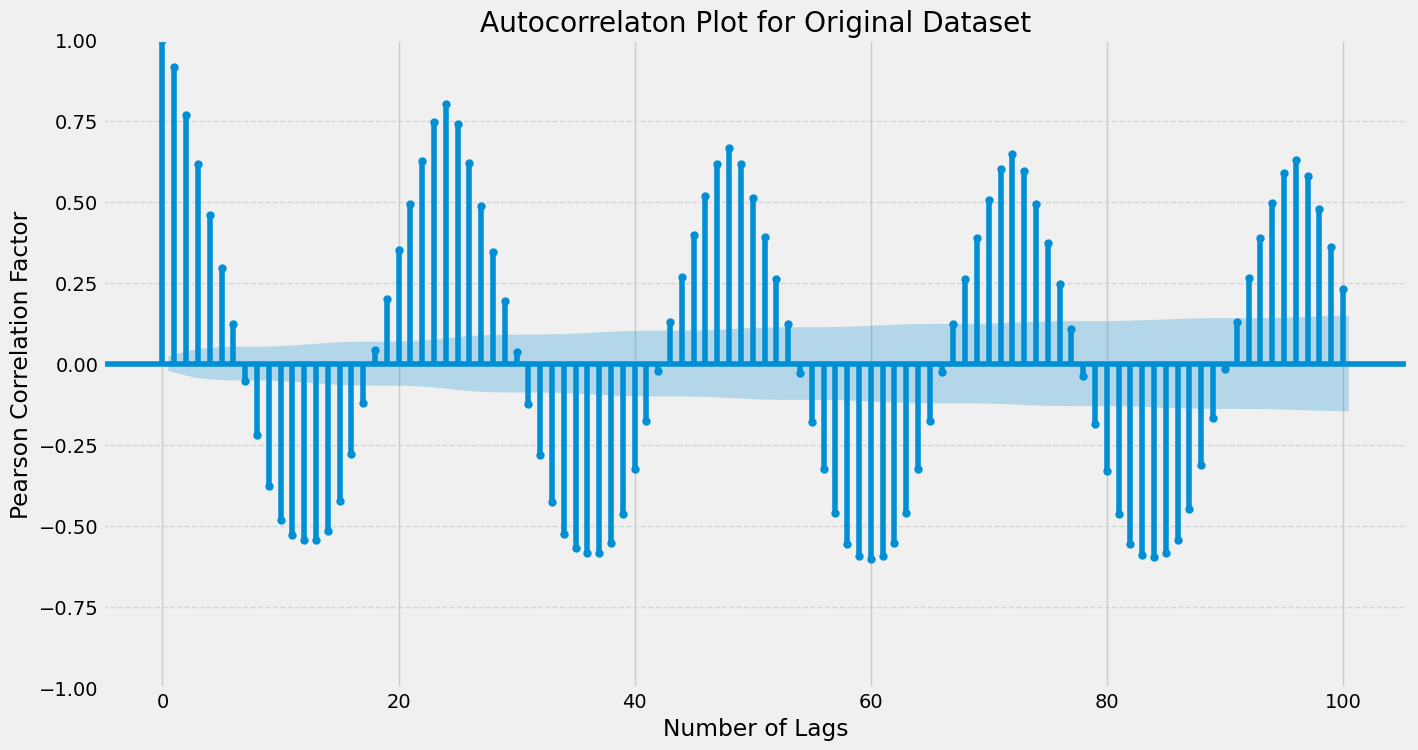

In [ ]:
fig1, ax1 = plt.subplots(figsize=(15,8))

plot_acf(df['activePowerT'],lags=100,ax=ax1,title="Autocorrelaton Plot for Original Dataset")
plt.xlabel("Number of Lags")
plt.ylabel("Pearson Correlation Factor")
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig1.savefig('/content/drive/MyDrive/Images/SARIMAX/ACF_original')

## PACF Plot

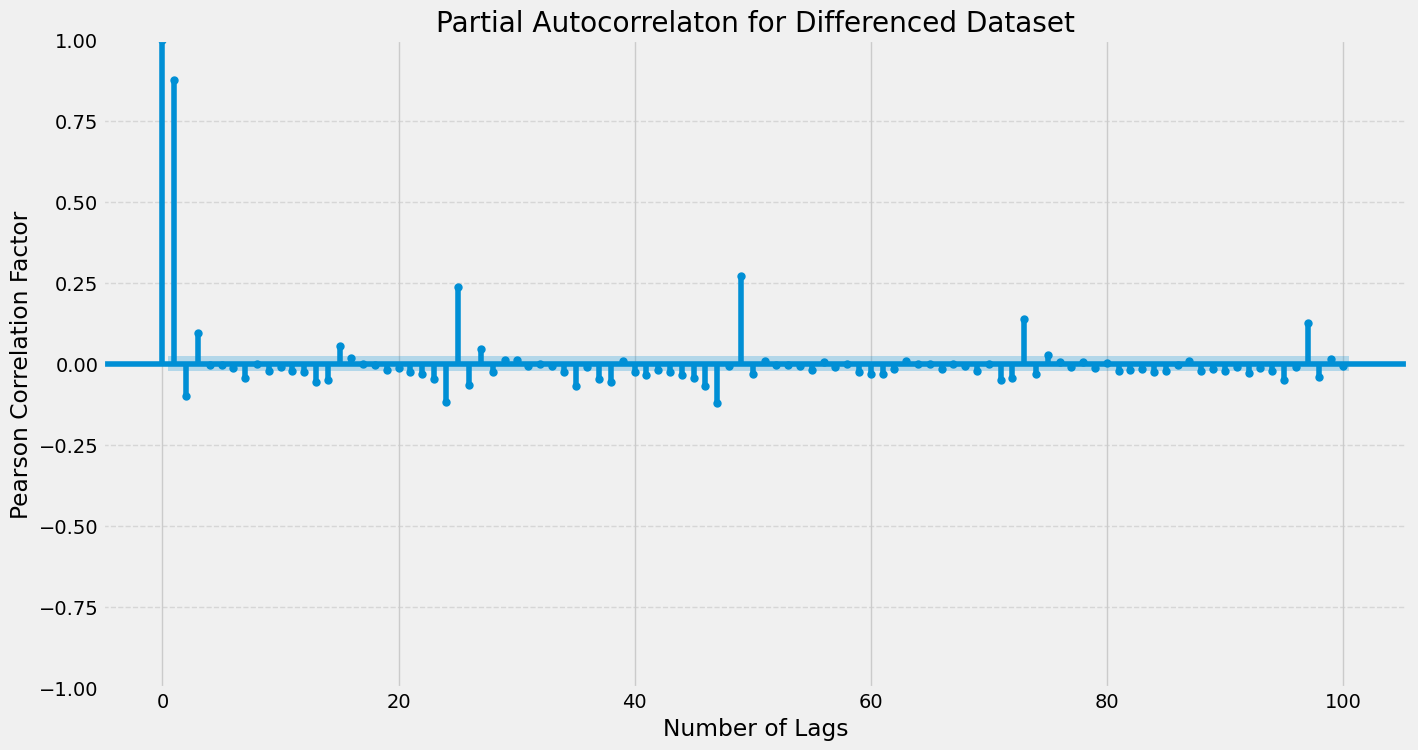

In [ ]:
fig1, ax1 = plt.subplots(figsize=(15,8))

plot_pacf(df['activePower_diff'],lags=100,ax=ax1,title="Partial Autocorrelaton for Differenced Dataset")
plt.xlabel("Number of Lags")
plt.ylabel("Pearson Correlation Factor")
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig1.savefig('/content/drive/MyDrive/Images/SARIMAX/PACF_daily')


## ACF Plot

The PACF Plot suggest that there is a cutoff after lag 7.

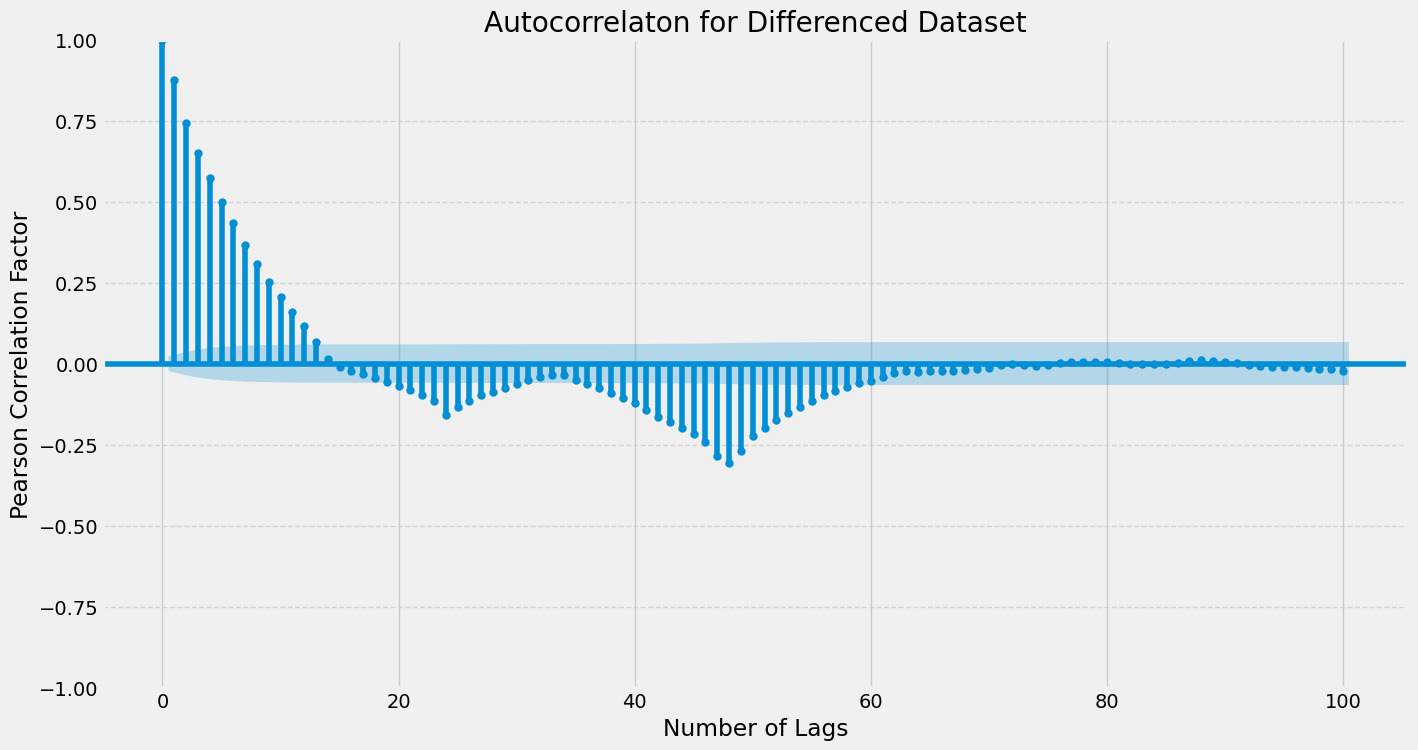

In [ ]:
fig2, ax2 = plt.subplots(figsize=(15,8))
plot_acf(df['activePower_diff'],lags=100,ax=ax2,title="Autocorrelaton for Differenced Dataset")
plt.xlabel("Number of Lags")
plt.ylabel("Pearson Correlation Factor")
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig2.savefig('/content/drive/MyDrive/Images/SARIMAX/ACF_daily')


The plot above shows a damped sinusoid where there is a significant spike at lag 7. This indicates that there is a seasonlity every 1 week. It can also be seen that at lag 21, there is a correlation factor which is considered significant. This implies that the system has a weekly seasonlity as well

# Time Series Decomposition

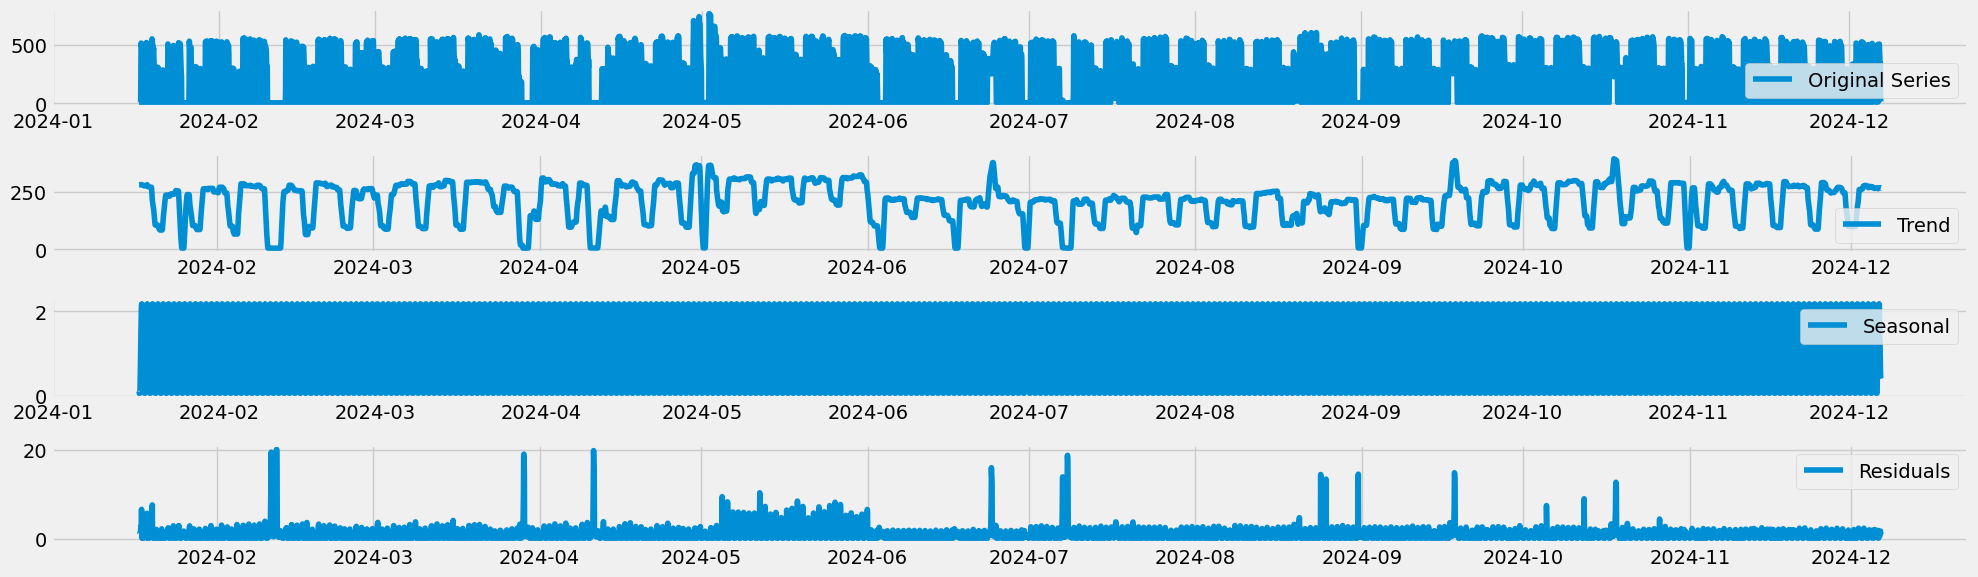

In [ ]:
result = seasonal_decompose(df['activePowerT'], model='multiplicative', period=24)
trend = result.trend.dropna()
seasonal = result.seasonal.dropna()
residual = result.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(20,6))

plt.subplot(4, 1, 1)
plt.plot(df['activePowerT'], label='Original Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()

## Exogenous Variables

In [ ]:
df=df.copy()
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['dayofyear'] = df.index.dayofyear
df['dayofmonth'] = df.index.day
target_map = df['activePowerT'].to_dict()
df['lag1'] = (df.index-pd.Timedelta('7 days')).map(target_map)
df['lag2'] = (df.index-pd.Timedelta('8 days')).map(target_map)
df['lag3'] = (df.index-pd.Timedelta('9 days')).map(target_map)
df['lag4'] = (df.index-pd.Timedelta('14 days')).map(target_map)
target_mapAA = df['activePowerA'].to_dict()
target_mapCA = df['currentA'].to_dict()

df['activePowerA_lag1']=(df.index-pd.Timedelta('7 days')).map(target_mapAA)
df['currentA_lag1']=(df.index-pd.Timedelta('7 days')).map(target_mapCA)
df.dropna(inplace=True)

## K-Fold Cross Validation

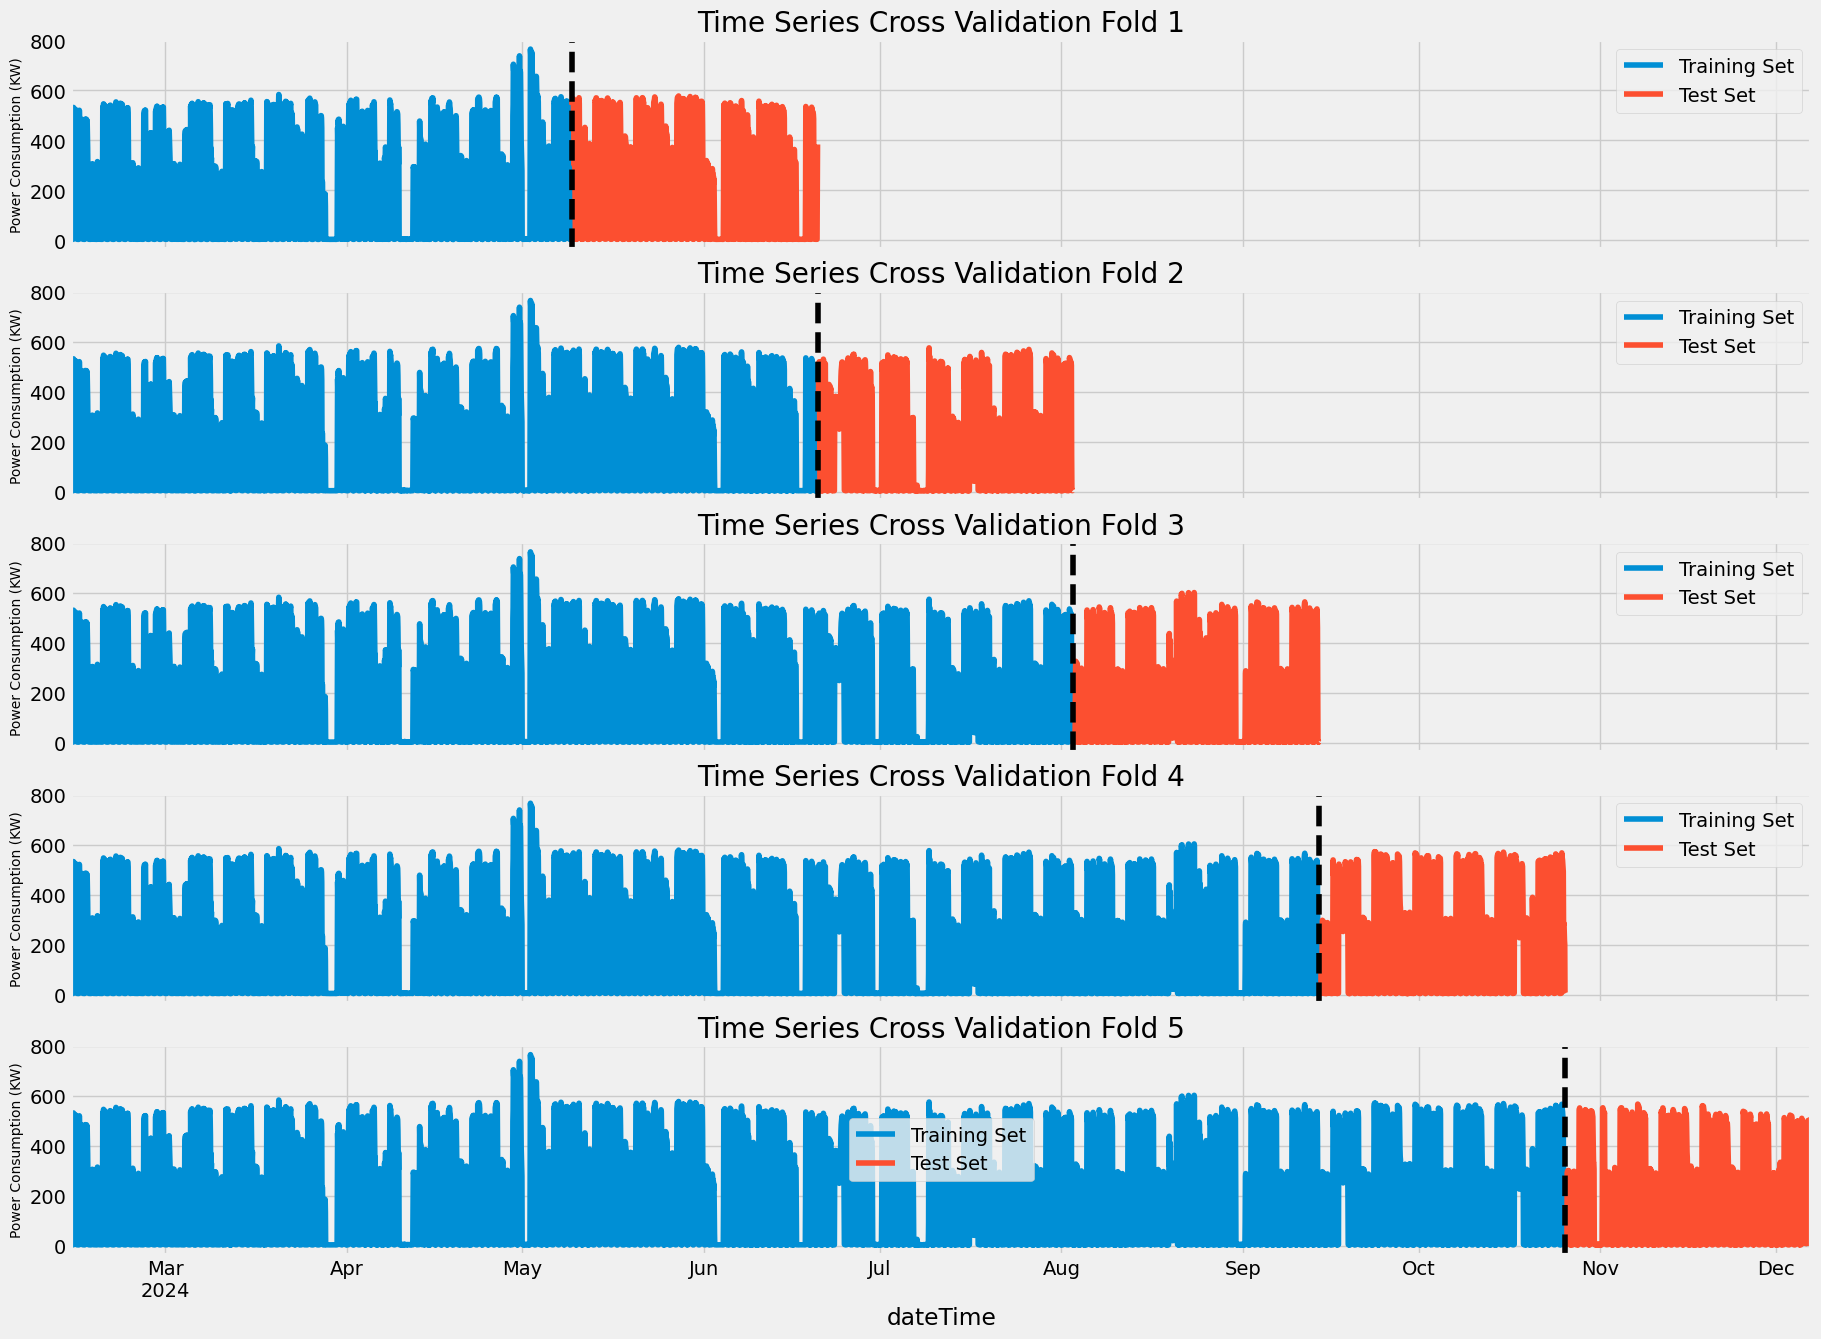

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5, test_size=14*24*3, gap=0)
df = df.sort_index()
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(20,15))

fold = 0

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['activePowerT'].plot(ax=axs[fold], label='Training Set',title=f'Time Series Cross Validation Fold {fold+1}')
    test['activePowerT'].plot(ax=axs[fold], label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    axs[fold].legend(['Training Set', 'Test Set'])
    axs[fold].set_ylabel('Power Consumption (KW)',fontsize=10)
    fold+=1

## SARIMA

In [ ]:
SARIMAX2_model = SARIMAX(train['activePowerT'],order=(1,0,0),seasonal_order=(1,1,1,24))
result2 = SARIMAX2_model.fit()
print(result2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         activePowerT   No. Observations:                 6082
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 24)   Log Likelihood              -33611.914
Date:                              Thu, 10 Apr 2025   AIC                          67231.829
Time:                                      02:23:58   BIC                          67258.665
Sample:                                           0   HQIC                         67241.144
                                             - 6082                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8711      0.005    191.688      0.000       0.862       0.880
ar.S.L24       0.32

Summary of ARIMA Model provides a lot of important information regarding our model.

In [ ]:
import numpy as np
fold = 0
score_mse = []
score_mae = []
preds = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    SARIMAX_model = SARIMAX(train['activePowerT'],order=(1,0,0),seasonal_order=(1,1,1,24))
    result = SARIMAX_model.fit()
    predictions = result.predict(start=train_idx.max()+1,end=val_idx.max())
    preds.append(predictions)
    score_mse.append(np.sqrt(mean_squared_error(test['activePowerT'],predictions)))
    score_mae.append(mean_absolute_error(test['activePowerT'],predictions))

## Auto ARIMA /SARIMA

In [ ]:
import pmdarima as pm
SARIMAX_model = pm.auto_arima(df[['activePowerT']],
                           start_p=3, start_q=0,
                           test='adf',
                           max_p=3, max_q=3,m=24,
                            seasonal=True,
                           D=1,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True,
                              scoring_args={'mse','mae','bic'})


In [ ]:
snaive_fc =[]
for row_idx,row in test.iterrows():
    day = row['hour']
    forecast = test['activePowerT'].loc[test['hour']==day].iloc[-1]
    snaive_fc.append(forecast)
snaive_fc = pd.Series(snaive_fc,index=test.index)

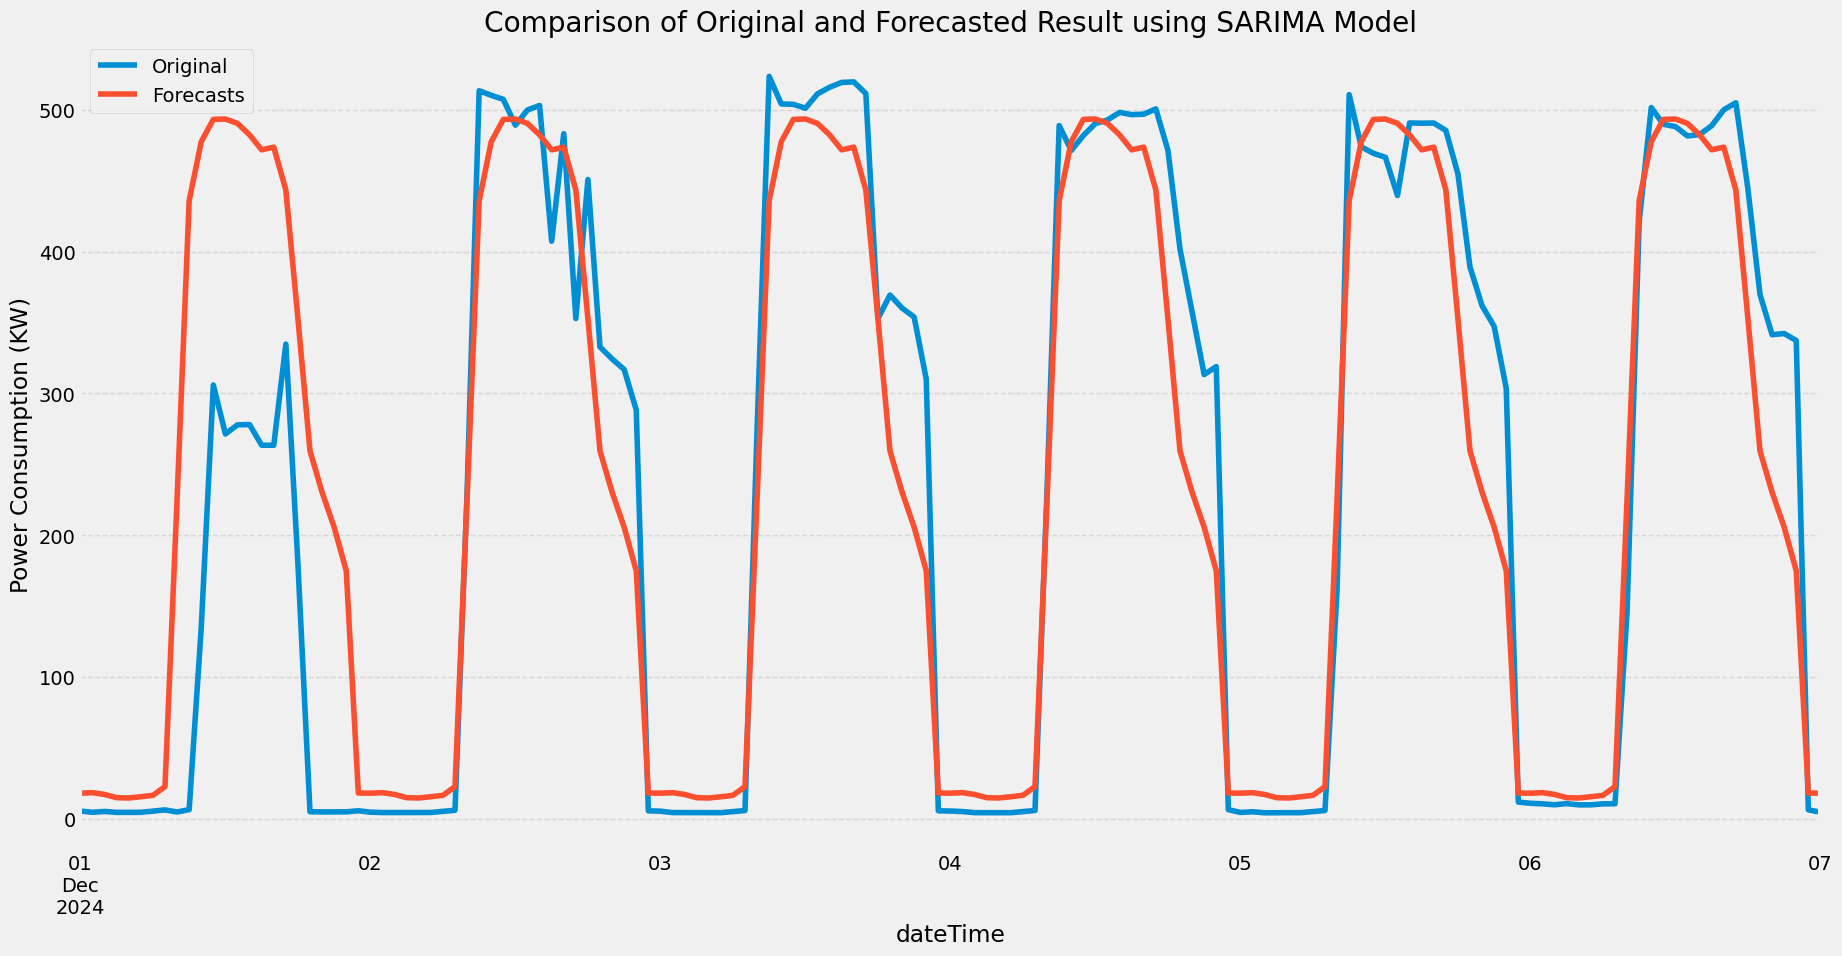

In [ ]:
predictions = result.predict(start=len(train),end=len(df)-1)
ax = df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['activePowerT'],title='Comparison of Original and Forecasted Result using SARIMA Model',xlabel='Date',ylabel='Power Consumption (KW)',figsize=(20,10))
predictions.loc[(predictions.index >= '2024-12-01') & (predictions.index < '2024-12-08')].plot(ax=ax,label="Forecasts")
ax.legend(['Original','Forecasts'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

fig = ax.get_figure()
fig.savefig('/content/drive/MyDrive/Images/SARIMAX/Results')

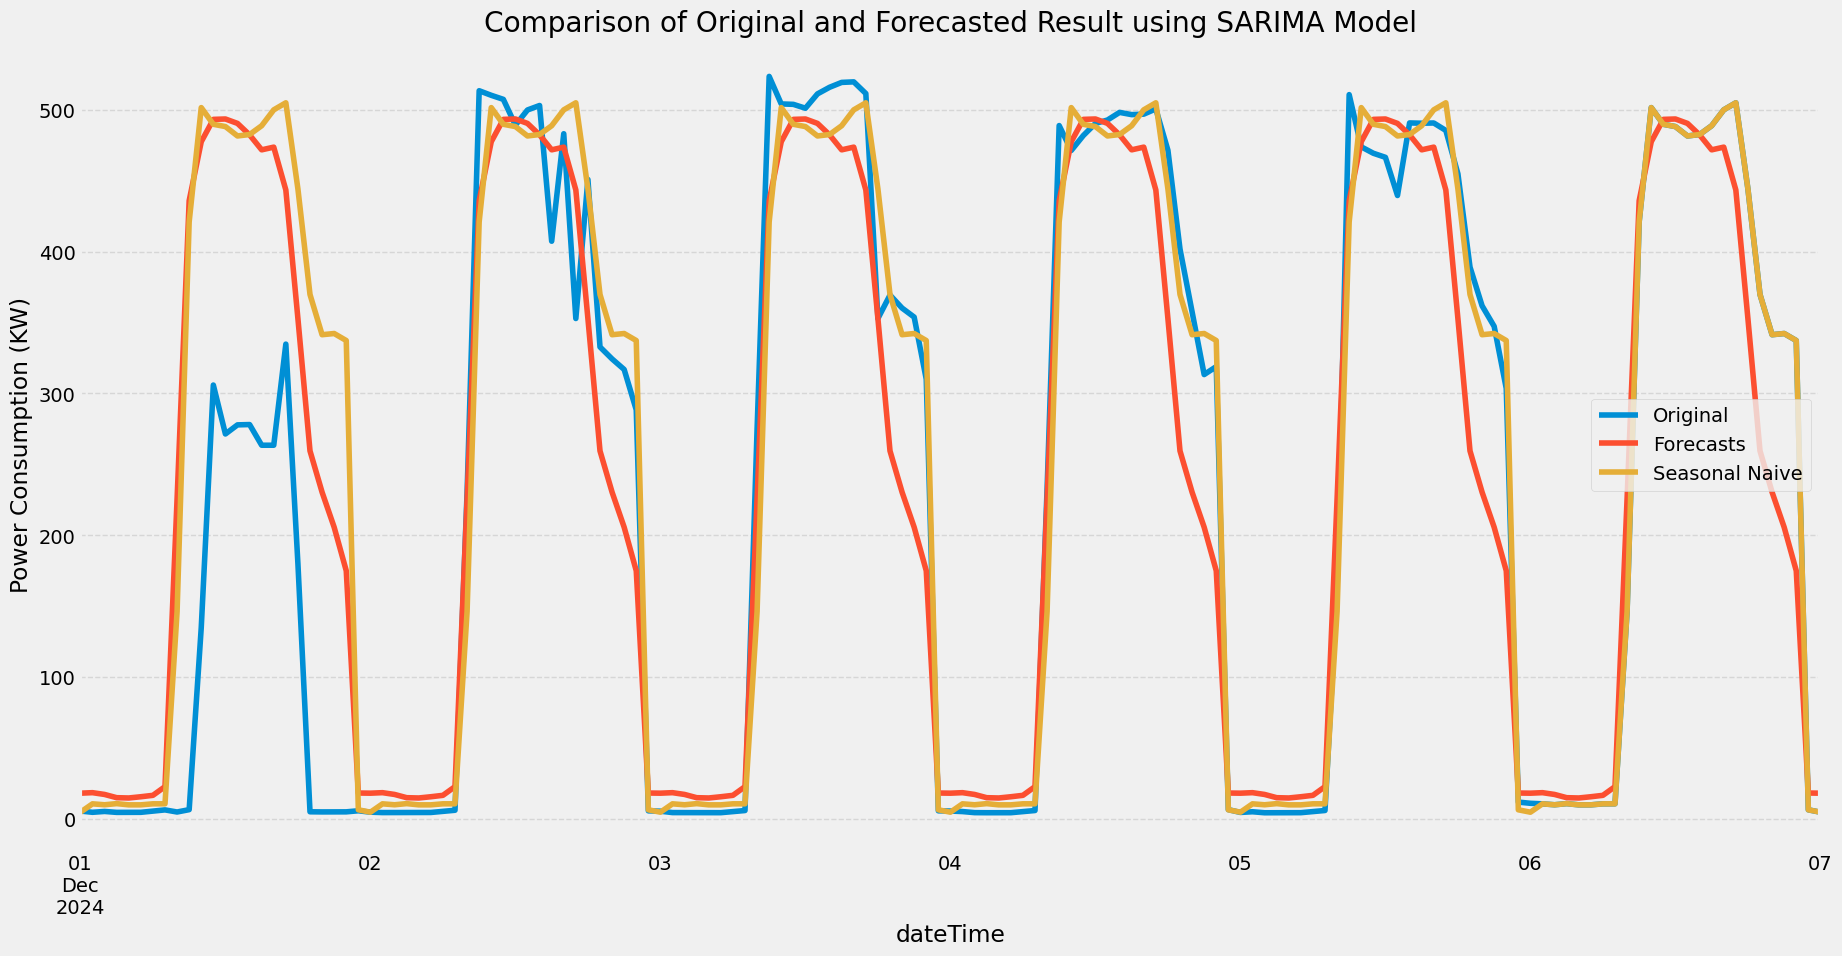

In [ ]:
ax = df.loc[(df.index >= '2024-12-01') & (df.index < '2024-12-08')].plot(y=['activePowerT'],title='Comparison of Original and Forecasted Result using SARIMA Model',xlabel='Date',ylabel='Power Consumption (KW)',figsize=(20,10))
predictions.loc[(predictions.index >= '2024-12-01') & (predictions.index < '2024-12-08')].plot(ax=ax,label="Forecasts")
snaive_fc.loc[(predictions.index >= '2024-12-01') & (predictions.index < '2024-12-08')].plot(label="Snaive")
ax.legend(['Original','Forecasts','Seasonal Naive'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Performance Evaluations

In [ ]:
import numpy as np

print(f'Average score (MSE) Advanced: {np.mean(score_mse):0.2f}')
print(f'Average score (MAE) Advanced: {np.mean(score_mae):0.2f}')

print("MSE3:",np.sqrt(mean_squared_error(test['activePowerT'],snaive_fc)))
print("MAE3:",mean_absolute_error(test['activePowerT'],snaive_fc))
print("MAPE3:",mean_absolute_percentage_error(test['activePowerT'],snaive_fc))
smape3 = np.mean((np.abs(test['activePowerT'] - snaive_fc)) /((np.abs(test['activePowerT']+np.abs(snaive_fc)) / 2))) * 100
print("SMAPE3: ",smape3,"%")

## Residuals Analysis

In [ ]:
result2.plot_diagnostics(figsize=(20,10))
plt.show()

Residuals are useful in checking the adequacy of our model. The top left graph shows the standardized residuals. It is observed they are occasional spikes of residuals. This implies that some of the models have residuals that would need to be removed or holidays and special event that have not been accounted for. The top right graphs shows the histogram. The histogram resembles a normal distribution which implies the residuals are normalized and constant variance. The bottom right graphs shows the correlogram which shows the correlation of residuals. It is seen that all of the residuals do not have correlation which is further verified using Ljung Box Test.

## Ljung-Box Test

In [ ]:
residuals = result2.test_serial_correlation(method='ljungbox',lags=20)
print(residuals[:,1])

The p-value of the test at lag 10 is 0.000071 which is much lower than 0.05. Thus, the hypothesis is rejected and conclude the the residuals are not correlated.